# 1. Environment Setup and Data Preprocessing
We load the "Fake News Detection" dataset and prepare it for the DistilBERT model. Instead of traditional NLP text cleaning, we leverage the powerful DistilBertTokenizer. This allows us to convert the raw text into token IDs and attention masks, ensuring the input is properly truncated and padded to a maximum length of 128 for tensor computation.


In [10]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive/')
file_path = "/content/drive/MyDrive/Colab Notebooks/fakenews.csv"
df = pd.read_csv(file_path)

df.head()

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


,text,label
0,Get the latest from TODAY Sign up for our news...,1
1,2d Conan On The Funeral Trump Will Be Invited...,1
2,It’s safe to say that Instagram Stories has fa...,0
3,Much like a certain Amazon goddess with a lass...,0
4,At a time when the perfect outfit is just one ...,0


In [11]:
from sklearn.model_selection import train_test_split
from transformers import DistilBertTokenizer
from torch.utils.data import DataLoader, Dataset
import torch
# Divide the training set and the test set, with the training set accounting for 80%
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['text'].tolist(), df['label'].tolist(), test_size=0.2, random_state=42
)

print(f"Training set size: {len(train_texts)}")
print(f"Testing set size: {len(test_texts)}")


tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Here, the tokenizer is directly called
        encoding = self.tokenizer(
            text,
            add_special_tokens=True, # Add special characters CLS and SEP
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create a DataLoader. Package the data in batches. Here, we first use batch_size=16
BATCH_SIZE = 16

train_dataset = FakeNewsDataset(train_texts, train_labels, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = FakeNewsDataset(test_texts, test_labels, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

sample_batch = next(iter(train_loader))
print(f"Input IDs: {sample_batch['input_ids'].shape}")
print(f"Attention Mask: {sample_batch['attention_mask'].shape}")
print(f"Labels: {sample_batch['labels'].shape}")

Training set size: 3988
Testing set size: 998
Input IDs: torch.Size([16, 128])
Attention Mask: torch.Size([16, 128])
Labels: torch.Size([16])


# 2. Base Model Training (DistilBERT Fine-tuning)
Here, we initialize the pre-trained distilbert-base-uncased model for sequence classification. We utilize the AdamW optimizer with a carefully selected learning rate of 2e-5 to prevent catastrophic forgetting of the pre-trained weights. The model is trained over 4 epochs using Cross-Entropy Loss. The training and testing metrics are recorded to visualize the convergence process.

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch [1/4] | Train Loss: 0.5592 | Train Acc: 0.7014 | Test Acc: 0.7395
Epoch [2/4] | Train Loss: 0.4034 | Train Acc: 0.8187 | Test Acc: 0.7896
Epoch [3/4] | Train Loss: 0.2592 | Train Acc: 0.8977 | Test Acc: 0.7946
Epoch [4/4] | Train Loss: 0.1339 | Train Acc: 0.9524 | Test Acc: 0.8016

 completed！


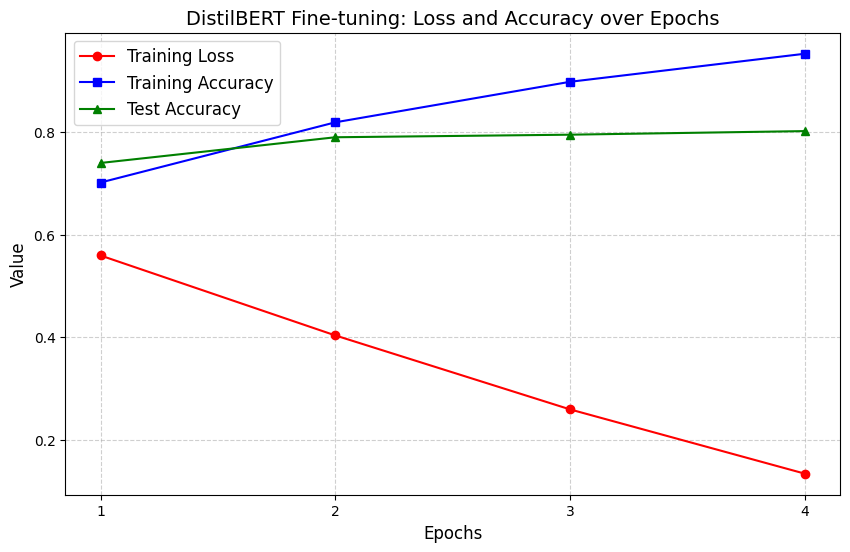

In [12]:
from transformers import DistilBertForSequenceClassification
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Loading the Model and Setting Hyperparameters
# num_labels=2 indicates that this is a binary classification task (true news/false news)
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
model.to(device)

# Core hyperparameters
LEARNING_RATE = 2e-5
EPOCHS = 4

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

# The loss function uses cross-entropy loss
criterion = nn.CrossEntropyLoss()

history_train_loss = []
history_train_acc = []
history_test_acc = []


# A large training and testing cycle
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    correct_train = 0
    total_train = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward propagation section
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        loss = criterion(logits, labels)
        total_loss += loss.item()

        # Backpropagation and parameter update section
        loss.backward()
        optimizer.step()

        _, preds = torch.max(logits, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    avg_train_loss = total_loss / len(train_loader)
    train_acc = correct_train / total_train


    # Test Section
    model.eval()
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            _, preds = torch.max(logits, dim=1)
            correct_test += (preds == labels).sum().item()
            total_test += labels.size(0)

    test_acc = correct_test / total_test

    history_train_loss.append(avg_train_loss)
    history_train_acc.append(train_acc)
    history_test_acc.append(test_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

print("\n completed！")


epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(10, 6))

plt.plot(epochs_range, history_train_loss, label='Training Loss', marker='o', color='red')
plt.plot(epochs_range, history_train_acc, label='Training Accuracy', marker='s', color='blue')
plt.plot(epochs_range, history_test_acc, label='Test Accuracy', marker='^', color='green')

plt.title('DistilBERT Fine-tuning: Loss and Accuracy over Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(epochs_range)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

# 3. Performance Visualization: First 100 Test Results
To intuitively evaluate the model's performance, this section extracts the first 100 instances from the test set. We process these text snippets through our fine-tuned model and compare the predicted labels against the actual ground truth. The results are presented in a structured tabular format for clear visualization.

In [13]:
import pandas as pd
from IPython.display import display

def generate_top_100_table(model, test_loader, tokenizer, device):
    model.eval()
    results = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            _, preds = torch.max(outputs.logits, dim=1)

            # Restore the text and compare the results
            for i in range(len(input_ids)):
                # Convert the token back to human-readable English words
                text = tokenizer.decode(input_ids[i], skip_special_tokens=True)

                # Extract the first 100 characters for display
                snippet = text[:100] + "..." if len(text) > 100 else text

                actual_label = "Fake" if labels[i].item() == 0 else "Real"
                predicted_label = "Fake" if preds[i].item() == 0 else "Real"

                results.append({
                    "News Snippet (First 100 chars)": snippet,
                    "Actual Label": actual_label,
                    "Predicted Label": predicted_label,
                    "Correct?": "✅" if actual_label == predicted_label else "❌"
                })

                if len(results) >= 100:
                    return pd.DataFrame(results)

    return pd.DataFrame(results)
df_results = generate_top_100_table(model, test_loader, tokenizer, device)
display(df_results)

,News Snippet (First 100 chars),Actual Label,Predicted Label,Correct?
0,"george timothy clooney ( born may 6, 1961 ) is...",Real,Real,✅
1,do you feel it in your fingers? do you feel it...,Fake,Fake,✅
2,advertisement the royal family gathered this m...,Fake,Fake,✅
3,"roger ailes, former fox news ceo, dies at 77 e...",Fake,Fake,✅
4,american serial child sexual abuser and physic...,Fake,Fake,✅
...,...,...,...,...
95,ed sheeran reveals ' love yourself ' was origi...,Real,Real,✅
96,get celebs updates directly to your inbox subs...,Real,Real,✅
97,mike walker reports … hollywood producers stok...,Real,Real,✅
98,the reality star and her husband are slapped w...,Fake,Fake,✅


# 4. Hyperparameter Tuning: The Impact of Learning Rates
This ablation study investigates the extreme sensitivity of pre-trained Transformer models to different learning rates. We compare the performance of standard learning rates commonly used in traditional networks (e.g., 0.01, 0.001) against the micro-learning rate (2e-5). This experiment aims to demonstrate the necessity of using small steps during fine-tuning to preserve the pre-trained language representations.

 The learning rate is being tested Learning Rate = 0.01


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch [1/4] | Train Loss: 0.7998 | Test Acc: 0.5822
Epoch [2/4] | Train Loss: 0.6741 | Test Acc: 0.5822
Epoch [3/4] | Train Loss: 0.6754 | Test Acc: 0.5822
Epoch [4/4] | Train Loss: 0.6742 | Test Acc: 0.5822
 The learning rate is being tested Learning Rate = 0.001


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch [1/4] | Train Loss: 0.5710 | Test Acc: 0.7796
Epoch [2/4] | Train Loss: 0.3979 | Test Acc: 0.7866
Epoch [3/4] | Train Loss: 0.2149 | Test Acc: 0.7695
Epoch [4/4] | Train Loss: 0.1042 | Test Acc: 0.7405
 The learning rate is being tested Learning Rate = 2e-05


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch [1/4] | Train Loss: 0.5627 | Test Acc: 0.7715
Epoch [2/4] | Train Loss: 0.3968 | Test Acc: 0.8056
Epoch [3/4] | Train Loss: 0.2637 | Test Acc: 0.7976
Epoch [4/4] | Train Loss: 0.1433 | Test Acc: 0.7916


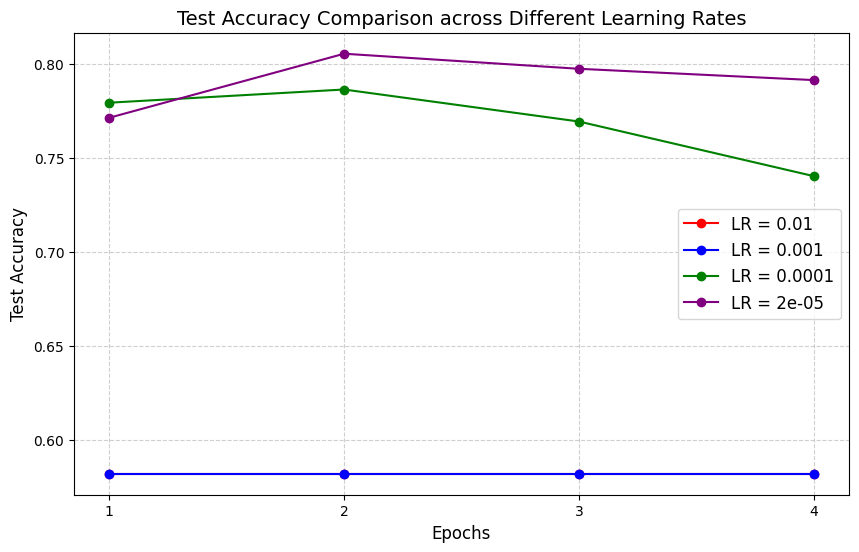

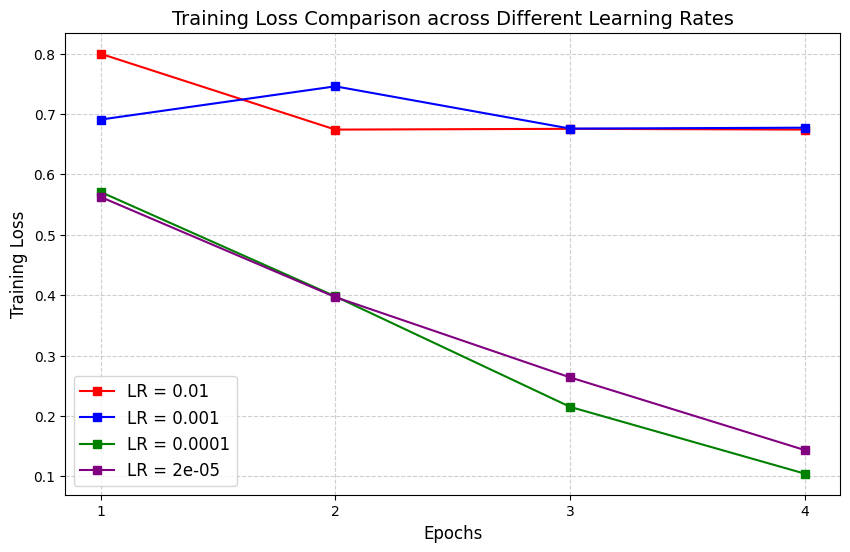

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import DistilBertForSequenceClassification
import matplotlib.pyplot as plt
import gc

# Define the learning rate we want to compare
learning_rates_to_test = [0.01, 0.001, 0.0001, 2e-5]
EPOCHS = 4

# Establish a dictionary to store all the experimental data
experiment_results = {}

for lr in learning_rates_to_test:
    print(f" The learning rate is being tested Learning Rate = {lr}")

    # Each experiment must reload an untrained initial model!
    model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    hist_train_loss, hist_train_acc, hist_test_acc = [], [], []

    for epoch in range(EPOCHS):
        # tainning part
        model.train()
        total_loss, correct_train, total_train = 0, 0, 0
        for batch in train_loader:
            optimizer.zero_grad()
            input_ids, attention_mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)
            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs.logits, dim=1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)

        # testing part
        model.eval()
        correct_test, total_test = 0, 0
        with torch.no_grad():
            for batch in test_loader:
                input_ids, attention_mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)
                outputs = model(input_ids, attention_mask=attention_mask)
                _, preds = torch.max(outputs.logits, dim=1)
                correct_test += (preds == labels).sum().item()
                total_test += labels.size(0)

        hist_train_loss.append(total_loss / len(train_loader))
        hist_train_acc.append(correct_train / total_train)
        hist_test_acc.append(correct_test / total_test)

        print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {hist_train_loss[-1]:.4f} | Test Acc: {hist_test_acc[-1]:.4f}")

    experiment_results[lr] = {
        'train_loss': hist_train_loss,
        'train_acc': hist_train_acc,
        'test_acc': hist_test_acc
    }

    del model, optimizer, criterion
    torch.cuda.empty_cache()
    gc.collect()


epochs_range = range(1, EPOCHS + 1)
colors = ['red', 'blue', 'green', 'purple']

# Figure 1: Test Accuracy
plt.figure(figsize=(10, 6))
for i, (lr, data) in enumerate(experiment_results.items()):
    plt.plot(epochs_range, data['test_acc'], label=f'LR = {lr}', marker='o', color=colors[i])

plt.title('Test Accuracy Comparison across Different Learning Rates', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.xticks(epochs_range)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Figure 2: Training Loss
plt.figure(figsize=(10, 6))
for i, (lr, data) in enumerate(experiment_results.items()):
    plt.plot(epochs_range, data['train_loss'], label=f'LR = {lr}', marker='s', color=colors[i])

plt.title('Training Loss Comparison across Different Learning Rates', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.xticks(epochs_range)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 5. Hyperparameter Tuning: The Impact of Batch Sizes
In this experiment, we analyze how different batch sizes (8, 16, 32, 64) affect model convergence and gradient stability. While fixing the optimal learning rate, we visualize the training loss and test accuracy. This helps us understand the trade-off between stochastic gradient oscillation (in smaller batches) and hardware memory limits (in larger batches).


The Batch Size is being tested = 8


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch [1/4] | Train Loss: 0.5518 | Test Acc: 0.7745
Epoch [2/4] | Train Loss: 0.3717 | Test Acc: 0.7826
Epoch [3/4] | Train Loss: 0.2250 | Test Acc: 0.7806
Epoch [4/4] | Train Loss: 0.1270 | Test Acc: 0.7886
The Batch Size is being tested = 16


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch [1/4] | Train Loss: 0.5829 | Test Acc: 0.7625
Epoch [2/4] | Train Loss: 0.4216 | Test Acc: 0.7776
Epoch [3/4] | Train Loss: 0.2981 | Test Acc: 0.7926
Epoch [4/4] | Train Loss: 0.1684 | Test Acc: 0.7856
The Batch Size is being tested = 64


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch [1/4] | Train Loss: 0.5995 | Test Acc: 0.7475
Epoch [2/4] | Train Loss: 0.4596 | Test Acc: 0.7695
Epoch [3/4] | Train Loss: 0.3498 | Test Acc: 0.7786
Epoch [4/4] | Train Loss: 0.2418 | Test Acc: 0.7886


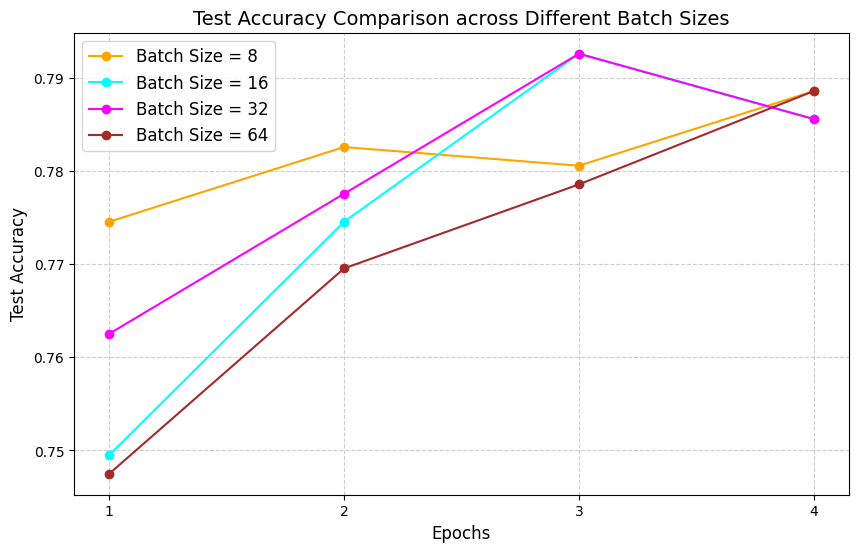

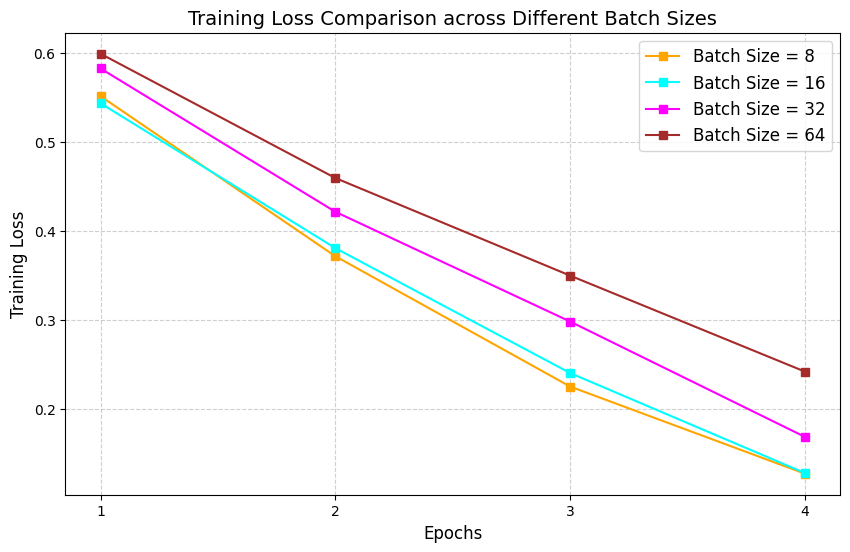

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import DistilBertForSequenceClassification
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import gc

# Define the Batch Sizes we want to compare
batch_sizes_to_test = [8, 16, 32, 64]
EPOCHS = 4
FIXED_LR = 2e-5

bs_experiment_results = {}

for bs in batch_sizes_to_test:
    print(f"The Batch Size is being tested = {bs}")

    current_train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    current_test_loader = DataLoader(test_dataset, batch_size=bs, shuffle=False)

    # Initialize the brand-new model and optimizer
    model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=FIXED_LR)
    criterion = nn.CrossEntropyLoss()

    hist_train_loss, hist_train_acc, hist_test_acc = [], [], []

    for epoch in range(EPOCHS):
        # tranning part
        model.train()
        total_loss, correct_train, total_train = 0, 0, 0
        for batch in current_train_loader:
            optimizer.zero_grad()
            input_ids, attention_mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)
            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs.logits, dim=1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)

        # testing part
        model.eval()
        correct_test, total_test = 0, 0
        with torch.no_grad():
            for batch in current_test_loader:
                input_ids, attention_mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)
                outputs = model(input_ids, attention_mask=attention_mask)
                _, preds = torch.max(outputs.logits, dim=1)
                correct_test += (preds == labels).sum().item()
                total_test += labels.size(0)

        hist_train_loss.append(total_loss / len(current_train_loader))
        hist_train_acc.append(correct_train / total_train)
        hist_test_acc.append(correct_test / total_test)

        print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {hist_train_loss[-1]:.4f} | Test Acc: {hist_test_acc[-1]:.4f}")

    bs_experiment_results[bs] = {
        'train_loss': hist_train_loss,
        'train_acc': hist_train_acc,
        'test_acc': hist_test_acc
    }

    del model, optimizer, criterion, current_train_loader, current_test_loader
    torch.cuda.empty_cache()
    gc.collect()


epochs_range = range(1, EPOCHS + 1)
colors = ['orange', 'cyan', 'magenta', 'brown']

# Figure 1: Test Accuracy
plt.figure(figsize=(10, 6))
for i, (bs, data) in enumerate(bs_experiment_results.items()):
    plt.plot(epochs_range, data['test_acc'], label=f'Batch Size = {bs}', marker='o', color=colors[i])

plt.title('Test Accuracy Comparison across Different Batch Sizes', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.xticks(epochs_range)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Figure 2: Training Loss
plt.figure(figsize=(10, 6))
for i, (bs, data) in enumerate(bs_experiment_results.items()):
    plt.plot(epochs_range, data['train_loss'], label=f'Batch Size = {bs}', marker='s', color=colors[i])

plt.title('Training Loss Comparison across Different Batch Sizes', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.xticks(epochs_range)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 6. Model Design: Loss Function Comparison (CrossEntropy vs. MSE)
To fulfill the model design requirements, we replace the standard Cross-Entropy Loss with Mean Squared Error (MSE) Loss. Since MSE is primarily designed for regression tasks, we apply a Sigmoid activation function to map the logits to a probability range of (0, 1). This section compares the training dynamics and final accuracy of these two distinct loss functions.

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch [1/4] | MSE Train Loss: 0.1870 | MSE Test Acc: 0.7685
Epoch [2/4] | MSE Train Loss: 0.1258 | MSE Test Acc: 0.7685
Epoch [3/4] | MSE Train Loss: 0.0834 | MSE Test Acc: 0.7826
Epoch [4/4] | MSE Train Loss: 0.0462 | MSE Test Acc: 0.7876


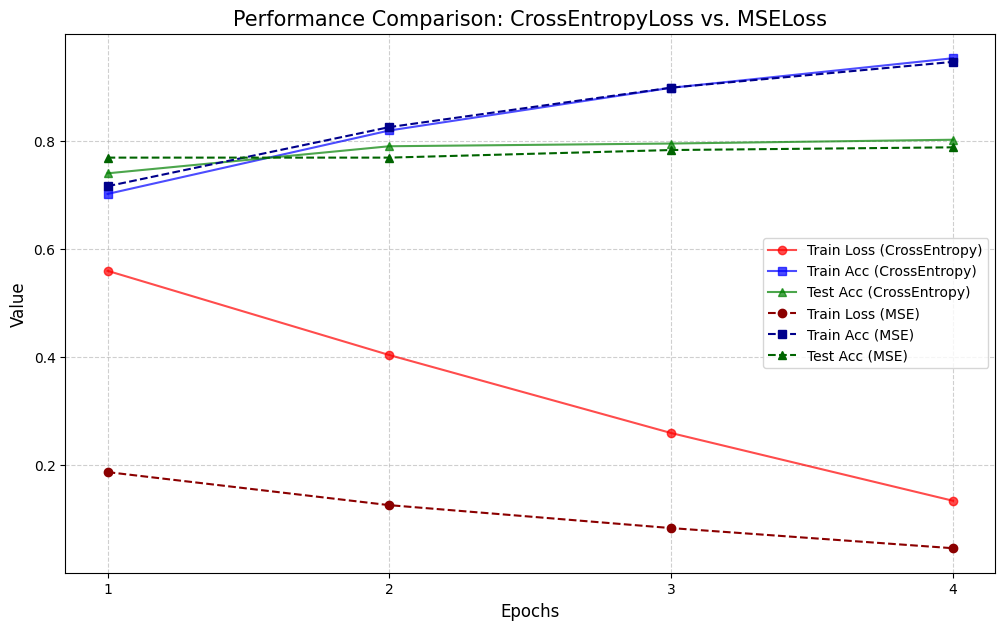

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import DistilBertForSequenceClassification
import matplotlib.pyplot as plt
import gc

EPOCHS = 4
FIXED_LR = 2e-5
BATCH_SIZE = 16

model_mse = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2).to(device)
optimizer_mse = optim.AdamW(model_mse.parameters(), lr=FIXED_LR)

# Switch to MSELoss
criterion_mse = nn.MSELoss()

# MSE requires comparing probability values with 0/1 labels, and we need Sigmoid
sigmoid = nn.Sigmoid()

hist_train_loss_mse = []
hist_train_acc_mse = []
hist_test_acc_mse = []

for epoch in range(EPOCHS):
    # trainning part
    model_mse.train()
    total_loss, correct_train, total_train = 0, 0, 0

    for batch in train_loader:
        optimizer_mse.zero_grad()
        input_ids, attention_mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)

        outputs = model_mse(input_ids, attention_mask=attention_mask)

        probs = sigmoid(outputs.logits[:, 1])
        float_labels = labels.float()

        loss = criterion_mse(probs, float_labels)
        total_loss += loss.item()
        loss.backward()
        optimizer_mse.step()

        preds = (probs > 0.5).long()
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    # testing part
    model_mse.eval()
    correct_test, total_test = 0, 0
    with torch.no_grad():
        for batch in test_loader:
            input_ids, attention_mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)
            outputs = model_mse(input_ids, attention_mask=attention_mask)

            probs = sigmoid(outputs.logits[:, 1])
            preds = (probs > 0.5).long()

            correct_test += (preds == labels).sum().item()
            total_test += labels.size(0)

    hist_train_loss_mse.append(total_loss / len(train_loader))
    hist_train_acc_mse.append(correct_train / total_train)
    hist_test_acc_mse.append(correct_test / total_test)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | MSE Train Loss: {hist_train_loss_mse[-1]:.4f} | MSE Test Acc: {hist_test_acc_mse[-1]:.4f}")

del model_mse, optimizer_mse
torch.cuda.empty_cache()
gc.collect()

epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(12, 7))

plt.plot(epochs_range, history_train_loss, label='Train Loss (CrossEntropy)', marker='o', linestyle='-', color='red', alpha=0.7)
plt.plot(epochs_range, history_train_acc, label='Train Acc (CrossEntropy)', marker='s', linestyle='-', color='blue', alpha=0.7)
plt.plot(epochs_range, history_test_acc, label='Test Acc (CrossEntropy)', marker='^', linestyle='-', color='green', alpha=0.7)

plt.plot(epochs_range, hist_train_loss_mse, label='Train Loss (MSE)', marker='o', linestyle='--', color='darkred')
plt.plot(epochs_range, hist_train_acc_mse, label='Train Acc (MSE)', marker='s', linestyle='--', color='darkblue')
plt.plot(epochs_range, hist_test_acc_mse, label='Test Acc (MSE)', marker='^', linestyle='--', color='darkgreen')

plt.title('Performance Comparison: CrossEntropyLoss vs. MSELoss', fontsize=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(epochs_range)
plt.legend(fontsize=10, loc='center right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()